In [1]:
%cd ../..
%load_ext autoreload
%autoreload 2

/nfs/scistore19/locatgrp/rcadei/artificial-causal-inference


# PPCI — Ants

Prediction-Powered Causal Inference on the ants grooming dataset.

## 0. Imports & config

In [2]:
SUBJECT = "ants"
ENCODER = "dinov2"
TOKEN   = "class"

In [3]:
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from src.ppci import (
    PPCIDataset, build_model, train, compute_metrics,
    aggregate_to_observations, compute_teb_all_pairs,
    plot_outcome_distribution_ants, plot_summary, plot_comparison,
)

cfg    = OmegaConf.load(f"configs/ppci/{SUBJECT}/config.yaml")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_ds_kwargs = dict(
    outcome_cols=list(cfg.outcome.columns),
    task=cfg.outcome.task,
    env_cols=list(cfg.environments.covariates),
    env_include_treatment=cfg.environments.include_treatment,
    n_val_videos=cfg.validation.n_videos,
    seed=cfg.training.seed,
)
outcomes = [c[len("Y_"):] for c in cfg.outcome.columns]

## 1. Dataset summary

Load a PPCIDataset from disk and inspect frame counts, treatment distribution, and outcome label balance.

In [4]:
ANNOTATED_VERSIONS = ["v1","v2","v3","v4"]

datasets = {}
for v in ANNOTATED_VERSIONS:
    datasets[v] = PPCIDataset.from_disk(SUBJECT, v, ENCODER, TOKEN, **_ds_kwargs)
    print(datasets[v])

Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v1/hf


Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

PPCIDataset summary:
  name            : ants v1
  total frames    : 396,000  (train=351,000, val=45,000)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: [0, 1, 2]
  obs per treatment: [14, 15, 15]
  env columns     : ['W_batch']
  n_envs (train)  : 5
  val videos      : ['d5', 'e3', 'd2', 'a5', 'b2']
Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v2/hf
PPCIDataset summary:
  name            : ants v2
  total frames    : 132,000  (train=117,000, val=15,000)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: [1, 2]
  obs per treatment: [24, 20]
  env columns     : ['W_batch']
  n_envs (train)  : 5
  val videos      : ['d5', 'e3', 'd2', 'a5', 'b2']
Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v3/hf


Loading dataset from disk:   0%|          | 0/25 [00:00<?, ?it/s]

PPCIDataset summary:
  name            : ants v3
  total frames    : 636,000  (train=621,000, val=15,000)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: [2, 4, 6, 7, 8, 9]
  obs per treatment: [38, 33, 34, 34, 35, 38]
  env columns     : ['W_batch']
  n_envs (train)  : 29
  val videos      : ['3_9_3', '3_15_2', '3_21_6', '3_7_3', '3_29_9']
Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v4/hf
PPCIDataset summary:
  name            : ants v4
  total frames    : 339,000  (train=324,000, val=15,000)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: [1, 2, 3, 4, 5, 6]
  obs per treatment: [20, 20, 20, 19, 14, 20]
  env columns     : ['W_batch']
  n_envs (train)  : 14
  val videos      : ['4_9_2', '4_1_2', '4_21_7', '4_10_8', '4_9_5']


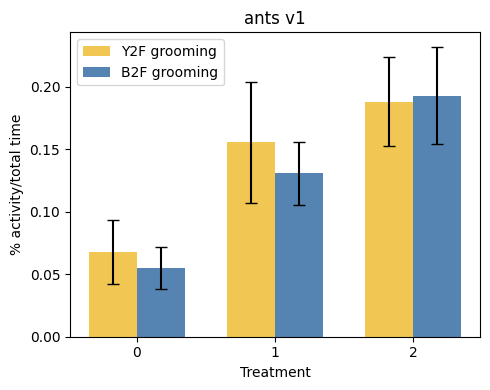

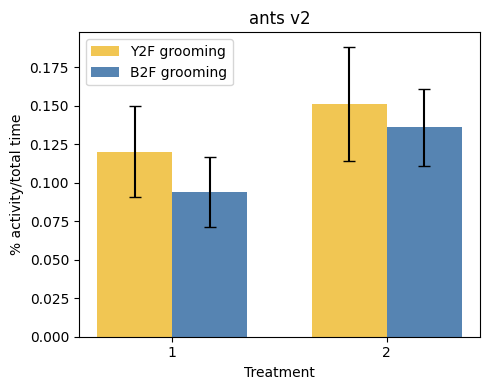

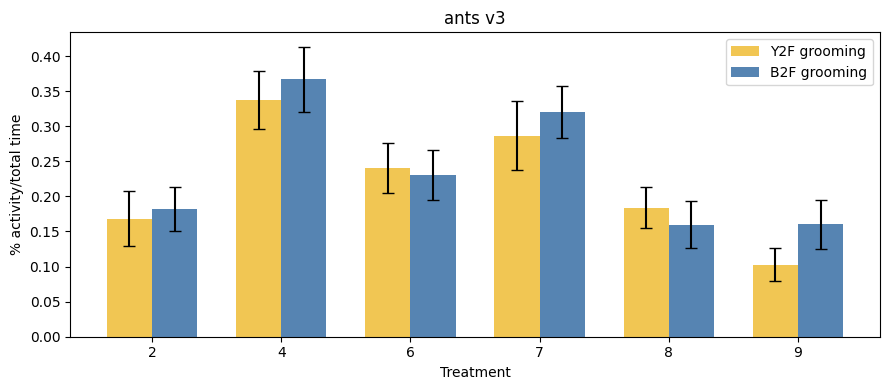

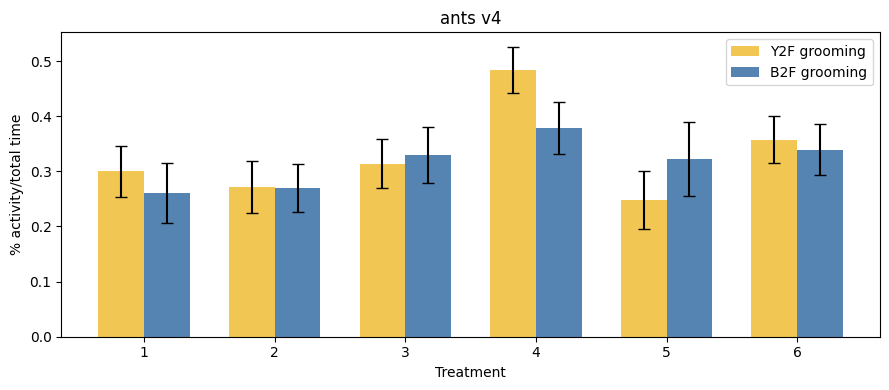

In [5]:
for ds in datasets.values():
    plot_outcome_distribution_ants(ds)

## 2. Single train

Train a model on one annotated dataset version (`ds_train`), then evaluate classification performance on the training distribution (validation split) and generalization to an out-of-distribution test set (`ds_test`).

In [6]:
ds_train, ds_test = datasets["v3"], datasets["v4"]

In [7]:
torch.manual_seed(cfg.training.seed)
best_model = train(ds_train, build_model(ds_train, cfg), cfg).to(device)

Epoch   1  train_loss=0.482  train_acc=0.907~  train_bacc=0.905~  train_recall=0.901~  train_precision=0.738~  val_acc=0.839  val_bacc=0.800  val_recall=0.733  val_precision=0.570
Epoch   2  train_loss=0.330  train_acc=0.925~  train_bacc=0.929~  train_recall=0.937~  train_precision=0.779~  val_acc=0.824  val_bacc=0.783  val_recall=0.702  val_precision=0.576
Epoch   3  train_loss=0.261  train_acc=0.935~  train_bacc=0.945~  train_recall=0.964~  train_precision=0.788~  val_acc=0.822  val_bacc=0.791  val_recall=0.734  val_precision=0.540
Epoch   4  train_loss=0.217  train_acc=0.940~  train_bacc=0.953~  train_recall=0.978~  train_precision=0.799~  val_acc=0.806  val_bacc=0.781  val_recall=0.730  val_precision=0.528
Epoch   5  train_loss=0.186  train_acc=0.948~  train_bacc=0.960~  train_recall=0.983~  train_precision=0.818~  val_acc=0.813  val_bacc=0.785  val_recall=0.741  val_precision=0.513


**Eval**: In-distribution

train — acc=0.905  bacc=0.904  recall=0.901  precision=0.737
val   — acc=0.839  bacc=0.800  recall=0.733  precision=0.570


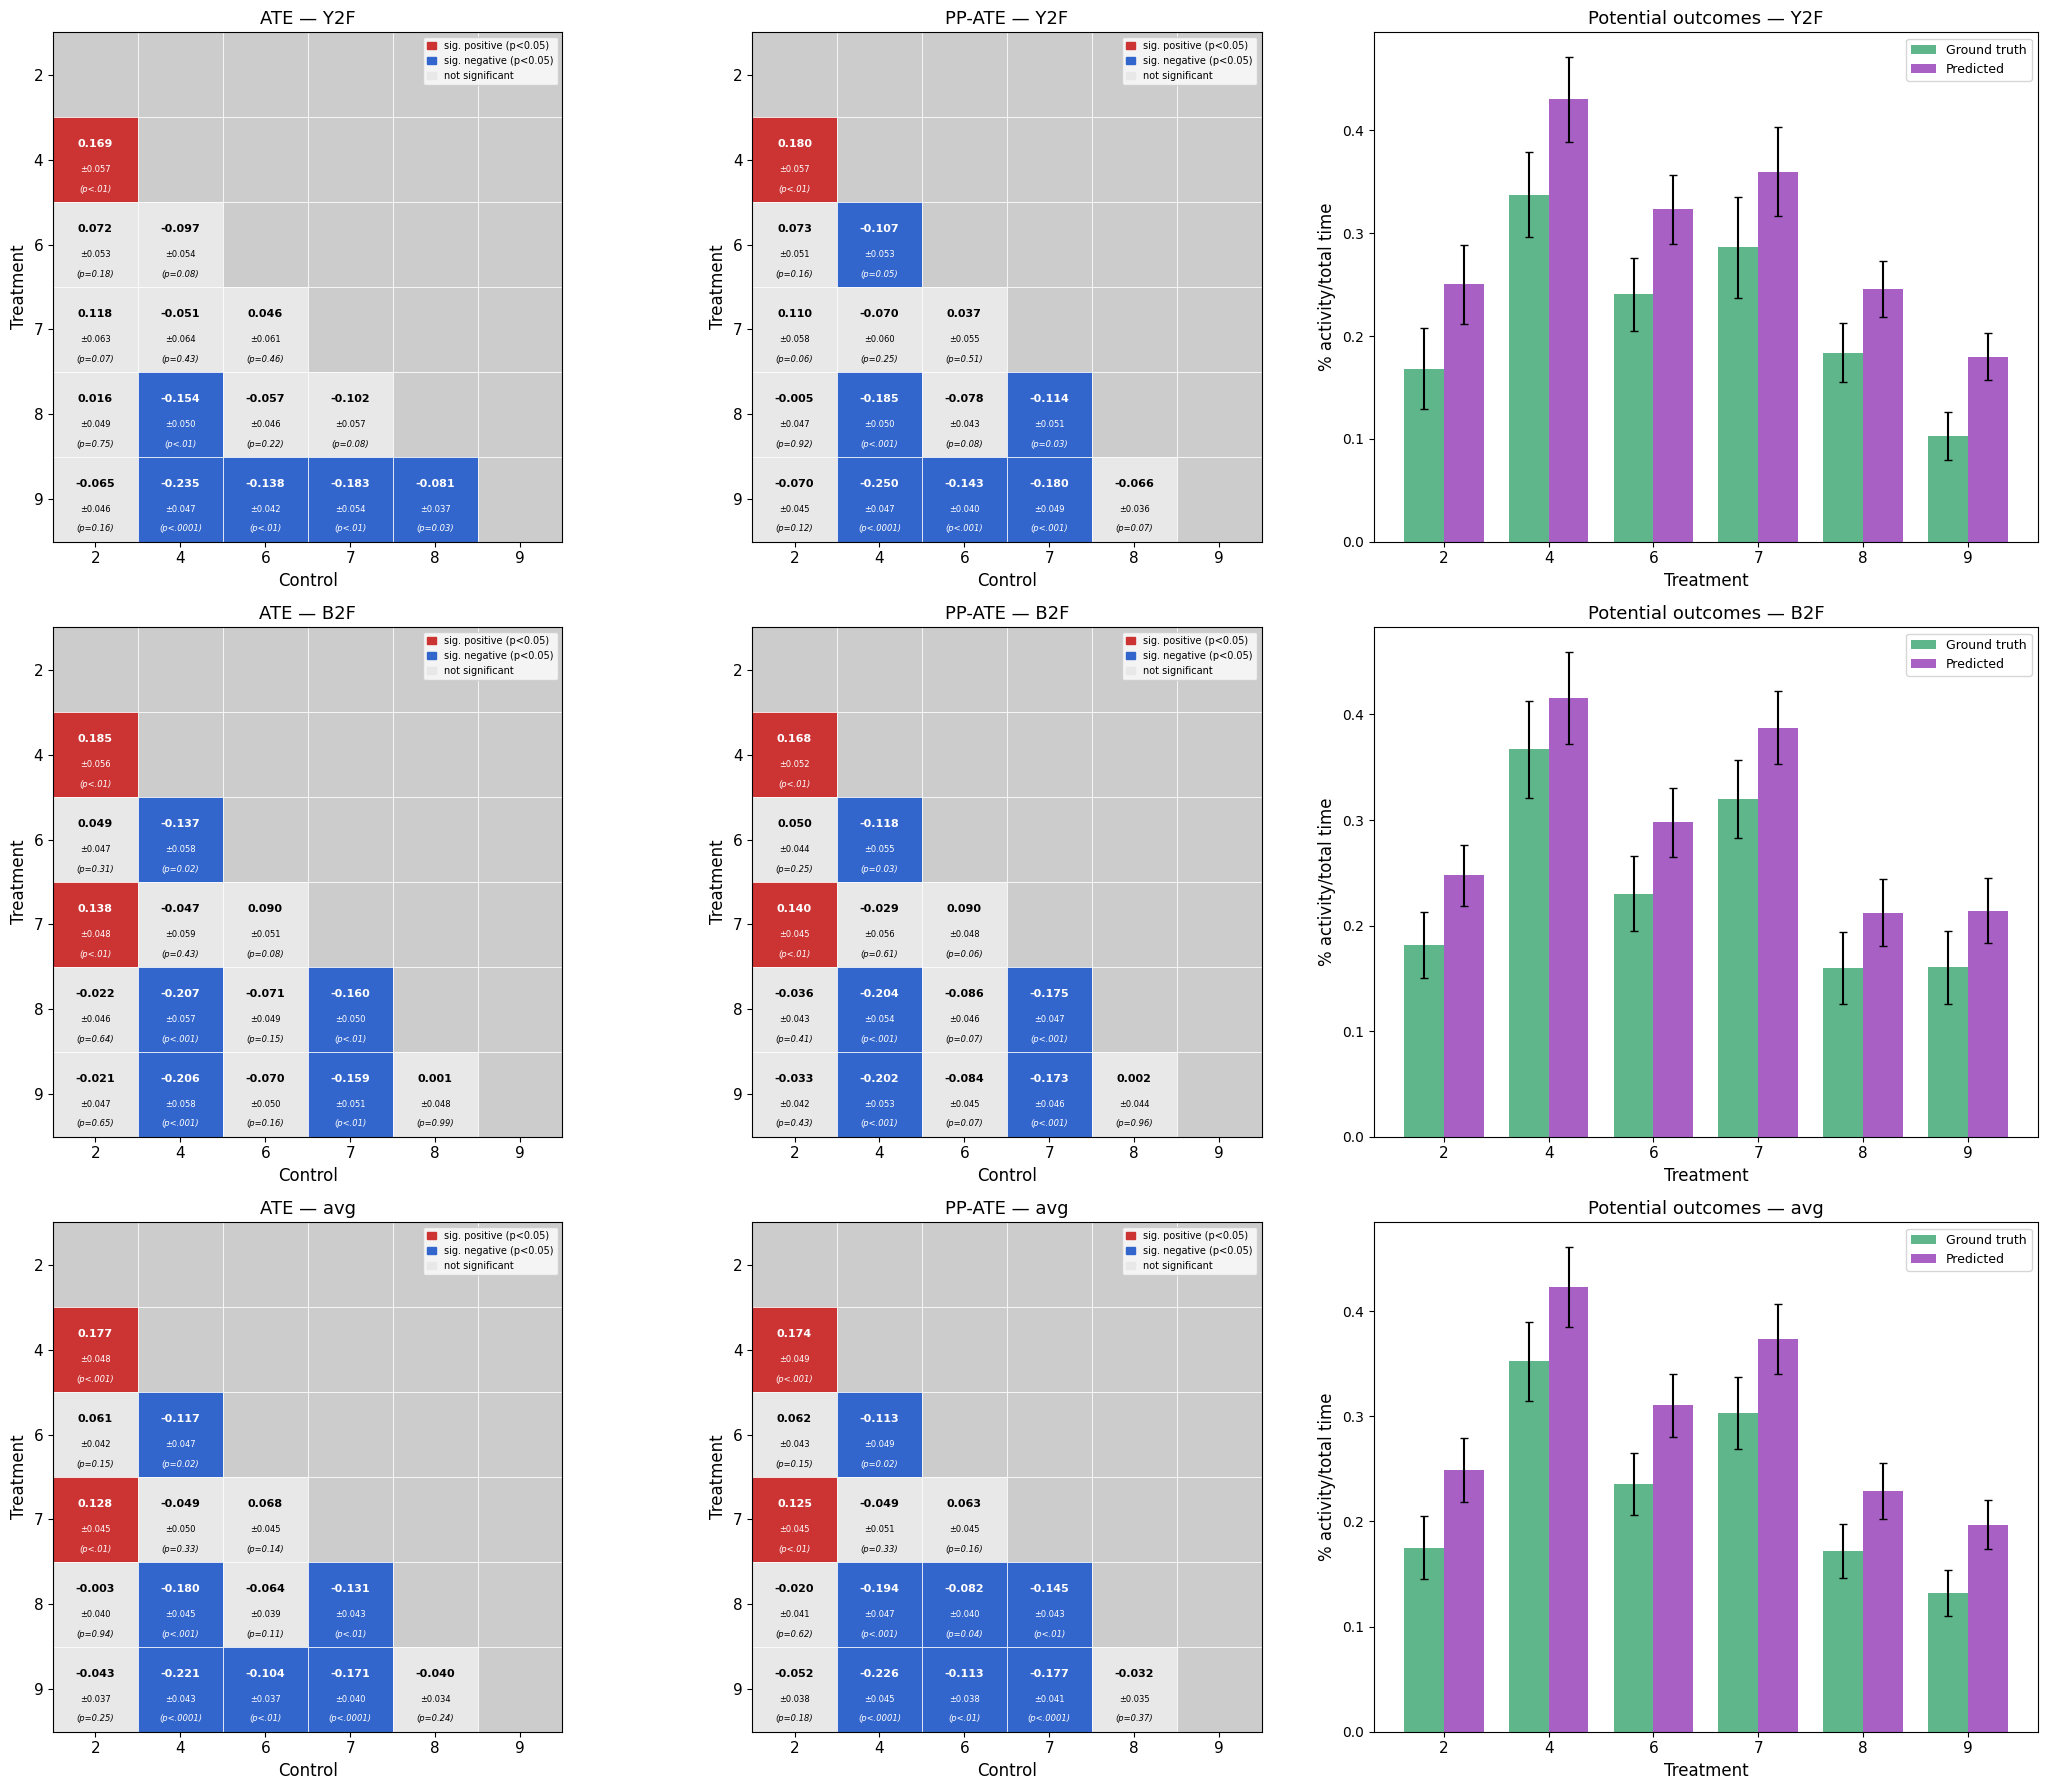

In [8]:
m_train = compute_metrics(best_model, ds_train.X_train, ds_train.Y_train, device)
m_val   = compute_metrics(best_model, ds_train.X_val,   ds_train.Y_val,   device)
print(f"train — acc={m_train['acc']:.3f}  bacc={m_train['bacc']:.3f}  recall={m_train['recall']:.3f}  precision={m_train['precision']:.3f}")
print(f"val   — acc={m_val['acc']:.3f}  bacc={m_val['bacc']:.3f}  recall={m_val['recall']:.3f}  precision={m_val['precision']:.3f}")
plot_summary(aggregate_to_observations(best_model, ds_train, device), outcomes, annotations=True)

**Eval:** Out-of-distribution

test  — acc=0.740  bacc=0.755  recall=0.798  precision=0.572


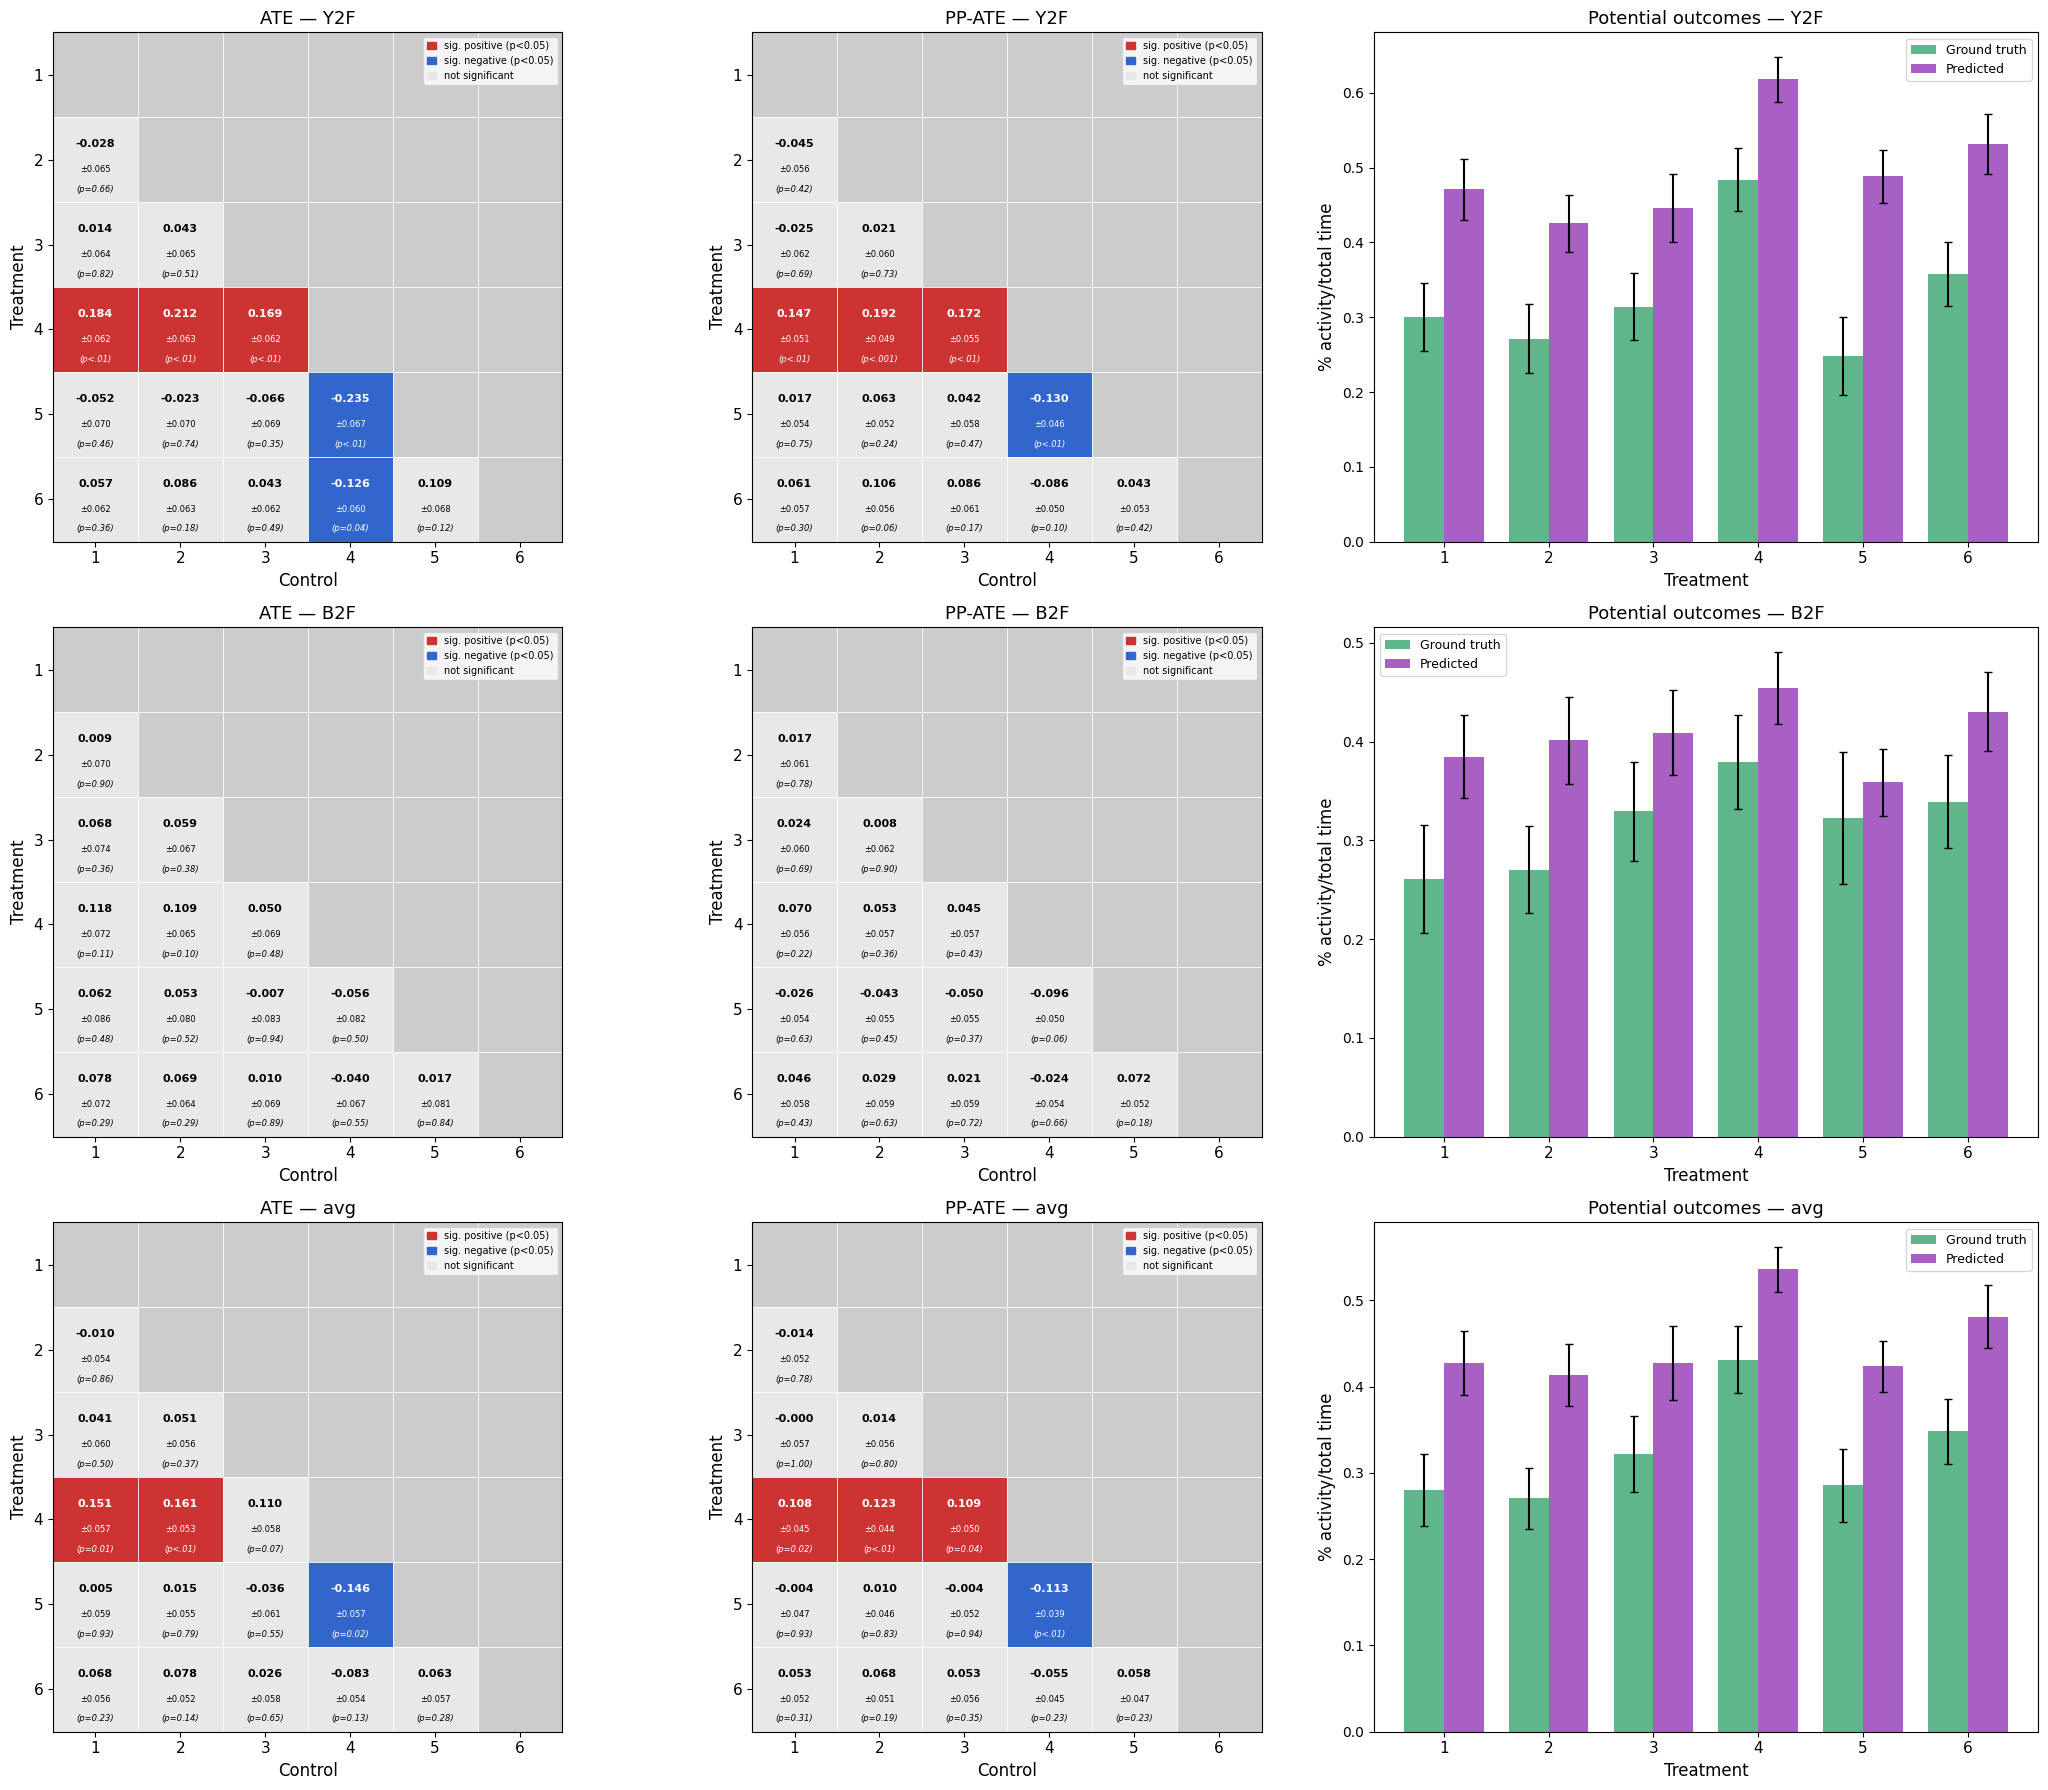

In [9]:
m_test = compute_metrics(best_model, ds_test.X, ds_test.Y, device)
print(f"test  — acc={m_test['acc']:.3f}  bacc={m_test['bacc']:.3f}  recall={m_test['recall']:.3f}  precision={m_test['precision']:.3f}")
plot_summary(aggregate_to_observations(best_model, ds_test, device), outcomes)

## 3. Compare methods

Train multiple methods (ERM, DERM, vREx, IRM) on `ds_train` and compare their classification metrics and causal effect estimates on `ds_test`.

In [10]:
METHODS = ["ERM", "vREx", "IRM", "DERM"]

results_val, results_test = {}, {}
for method in METHODS:
    print(f"\n── {method} ──")
    m_cfg = OmegaConf.merge(cfg, OmegaConf.create({"training": {"method": method, "seed": 0}}))
    torch.manual_seed(0)
    best = train(ds_train, build_model(ds_train, m_cfg), m_cfg).to(device)
    m_val  = compute_metrics(best, ds_train.X_val, ds_train.Y_val, device)
    m_test = compute_metrics(best, ds_test.X, ds_test.Y, device)
    _, summary_train = compute_teb_all_pairs(best, ds_train, device, methods=["ead"])
    _, summary_test  = compute_teb_all_pairs(best, ds_test,  device, methods=["ead"])
    results_val[method]  = {"acc": m_val["acc"],  "precision": m_val["precision"],
                             "recall": m_val["recall"],  "summary_df": summary_train}
    results_test[method] = {"acc": m_test["acc"], "precision": m_test["precision"],
                             "recall": m_test["recall"], "summary_df": summary_test}


── ERM ──
Epoch   1  train_loss=0.482  train_acc=0.907~  train_bacc=0.905~  train_recall=0.901~  train_precision=0.738~  val_acc=0.839  val_bacc=0.800  val_recall=0.733  val_precision=0.570
Epoch   2  train_loss=0.330  train_acc=0.925~  train_bacc=0.929~  train_recall=0.937~  train_precision=0.779~  val_acc=0.824  val_bacc=0.783  val_recall=0.702  val_precision=0.576
Epoch   3  train_loss=0.261  train_acc=0.935~  train_bacc=0.945~  train_recall=0.964~  train_precision=0.788~  val_acc=0.822  val_bacc=0.791  val_recall=0.734  val_precision=0.540
Epoch   4  train_loss=0.217  train_acc=0.940~  train_bacc=0.953~  train_recall=0.978~  train_precision=0.799~  val_acc=0.806  val_bacc=0.781  val_recall=0.730  val_precision=0.528
Epoch   5  train_loss=0.186  train_acc=0.948~  train_bacc=0.960~  train_recall=0.983~  train_precision=0.818~  val_acc=0.813  val_bacc=0.785  val_recall=0.741  val_precision=0.513

── vREx ──
Epoch   1  train_loss=0.949  train_acc=0.748~  train_bacc=0.757~  train_recal

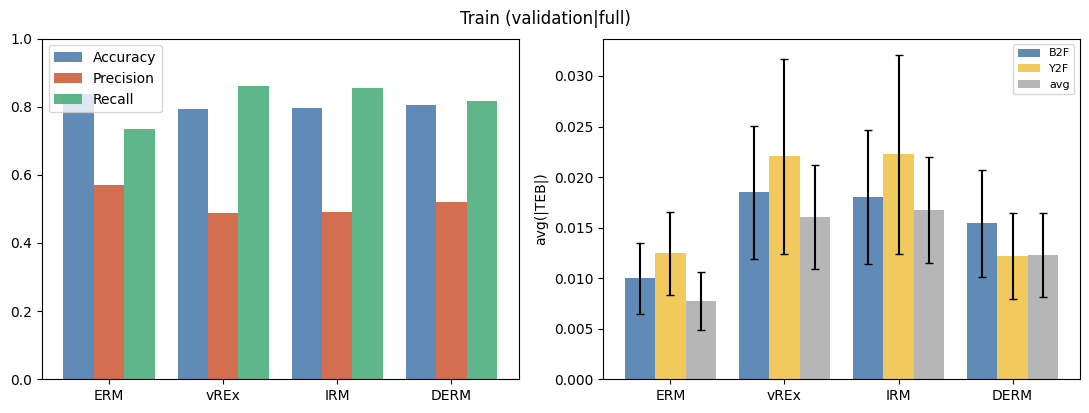

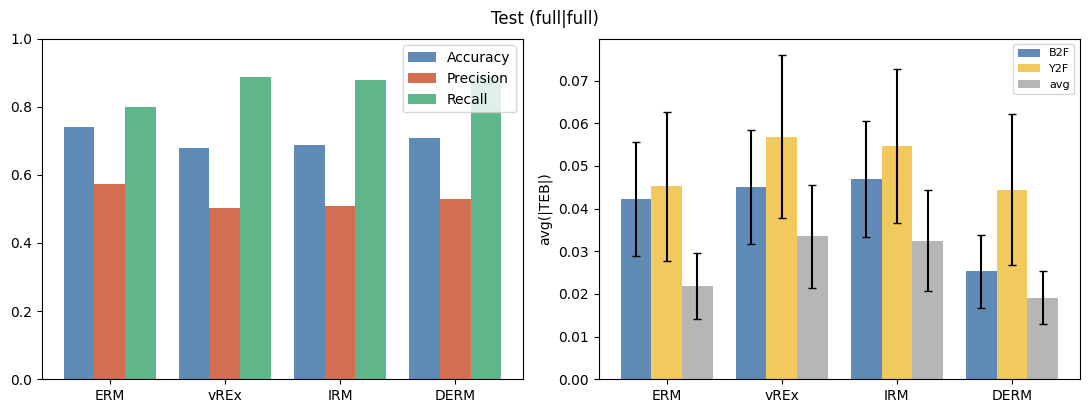

In [11]:
fig = plot_comparison(results_val)
fig.suptitle("Train (validation|full)", y=1.02)
plt.show()

fig = plot_comparison(results_test)
fig.suptitle("Test (full|full)", y=1.02)
plt.show()

## 4. Deployment

Train on all available annotated data (`ds_train`) and estimate causal effects on a new unannotated dataset (`ds_test`).

In [30]:
# For deployment: reload train datasets with n_val_videos=0 to include all data in training
_deploy_kwargs = {**_ds_kwargs, "n_val_videos": 0}
ds_train   = PPCIDataset.concat([PPCIDataset.from_disk(SUBJECT, "v3", ENCODER, TOKEN, **_deploy_kwargs), 
                                 PPCIDataset.from_disk(SUBJECT, "v4", ENCODER, TOKEN, **_deploy_kwargs)])
ds_test    = PPCIDataset.from_disk(SUBJECT, "v5", ENCODER, TOKEN, **{**_ds_kwargs, "n_val_videos": 0})
print(ds_train)
print(ds_test)

Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v3/hf


Loading dataset from disk:   0%|          | 0/25 [00:00<?, ?it/s]

Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v4/hf
Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v5/hf


Loading dataset from disk:   0%|          | 0/33 [00:00<?, ?it/s]

PPCIDataset summary:
  name            : ants v3 + ants v4
  total frames    : 975,000  (train=975,000, val=0)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: ['1', '2', '3', '4', '5', '6', '7', '8', '9']
  obs per treatment: [20, 58, 20, 52, 14, 54, 34, 35, 38]
  env columns     : ['W_batch']
  n_envs (train)  : 43
  val videos      : []
PPCIDataset summary:
  name            : ants v5
  total frames    : 681,000  (train=681,000, val=0)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: ['A', 'B', 'C', 'D', 'E', 'F']
  obs per treatment: [42, 38, 35, 38, 36, 38]
  env columns     : ['W_batch']
  n_envs (train)  : 29
  val videos      : []


In [31]:
torch.manual_seed(cfg.training.seed)
best_multi = train(ds_train, build_model(ds_train, cfg), cfg).to(device)

Epoch   1  train_loss=0.492  train_acc=0.888~  train_bacc=0.893~  train_recall=0.904~  train_precision=0.729~
Epoch   2  train_loss=0.347  train_acc=0.916~  train_bacc=0.924~  train_recall=0.940~  train_precision=0.779~
Epoch   3  train_loss=0.281  train_acc=0.929~  train_bacc=0.940~  train_recall=0.961~  train_precision=0.803~
Epoch   4  train_loss=0.240  train_acc=0.947~  train_bacc=0.949~  train_recall=0.954~  train_precision=0.856~
Epoch   5  train_loss=0.210  train_acc=0.949~  train_bacc=0.956~  train_recall=0.970~  train_precision=0.854~


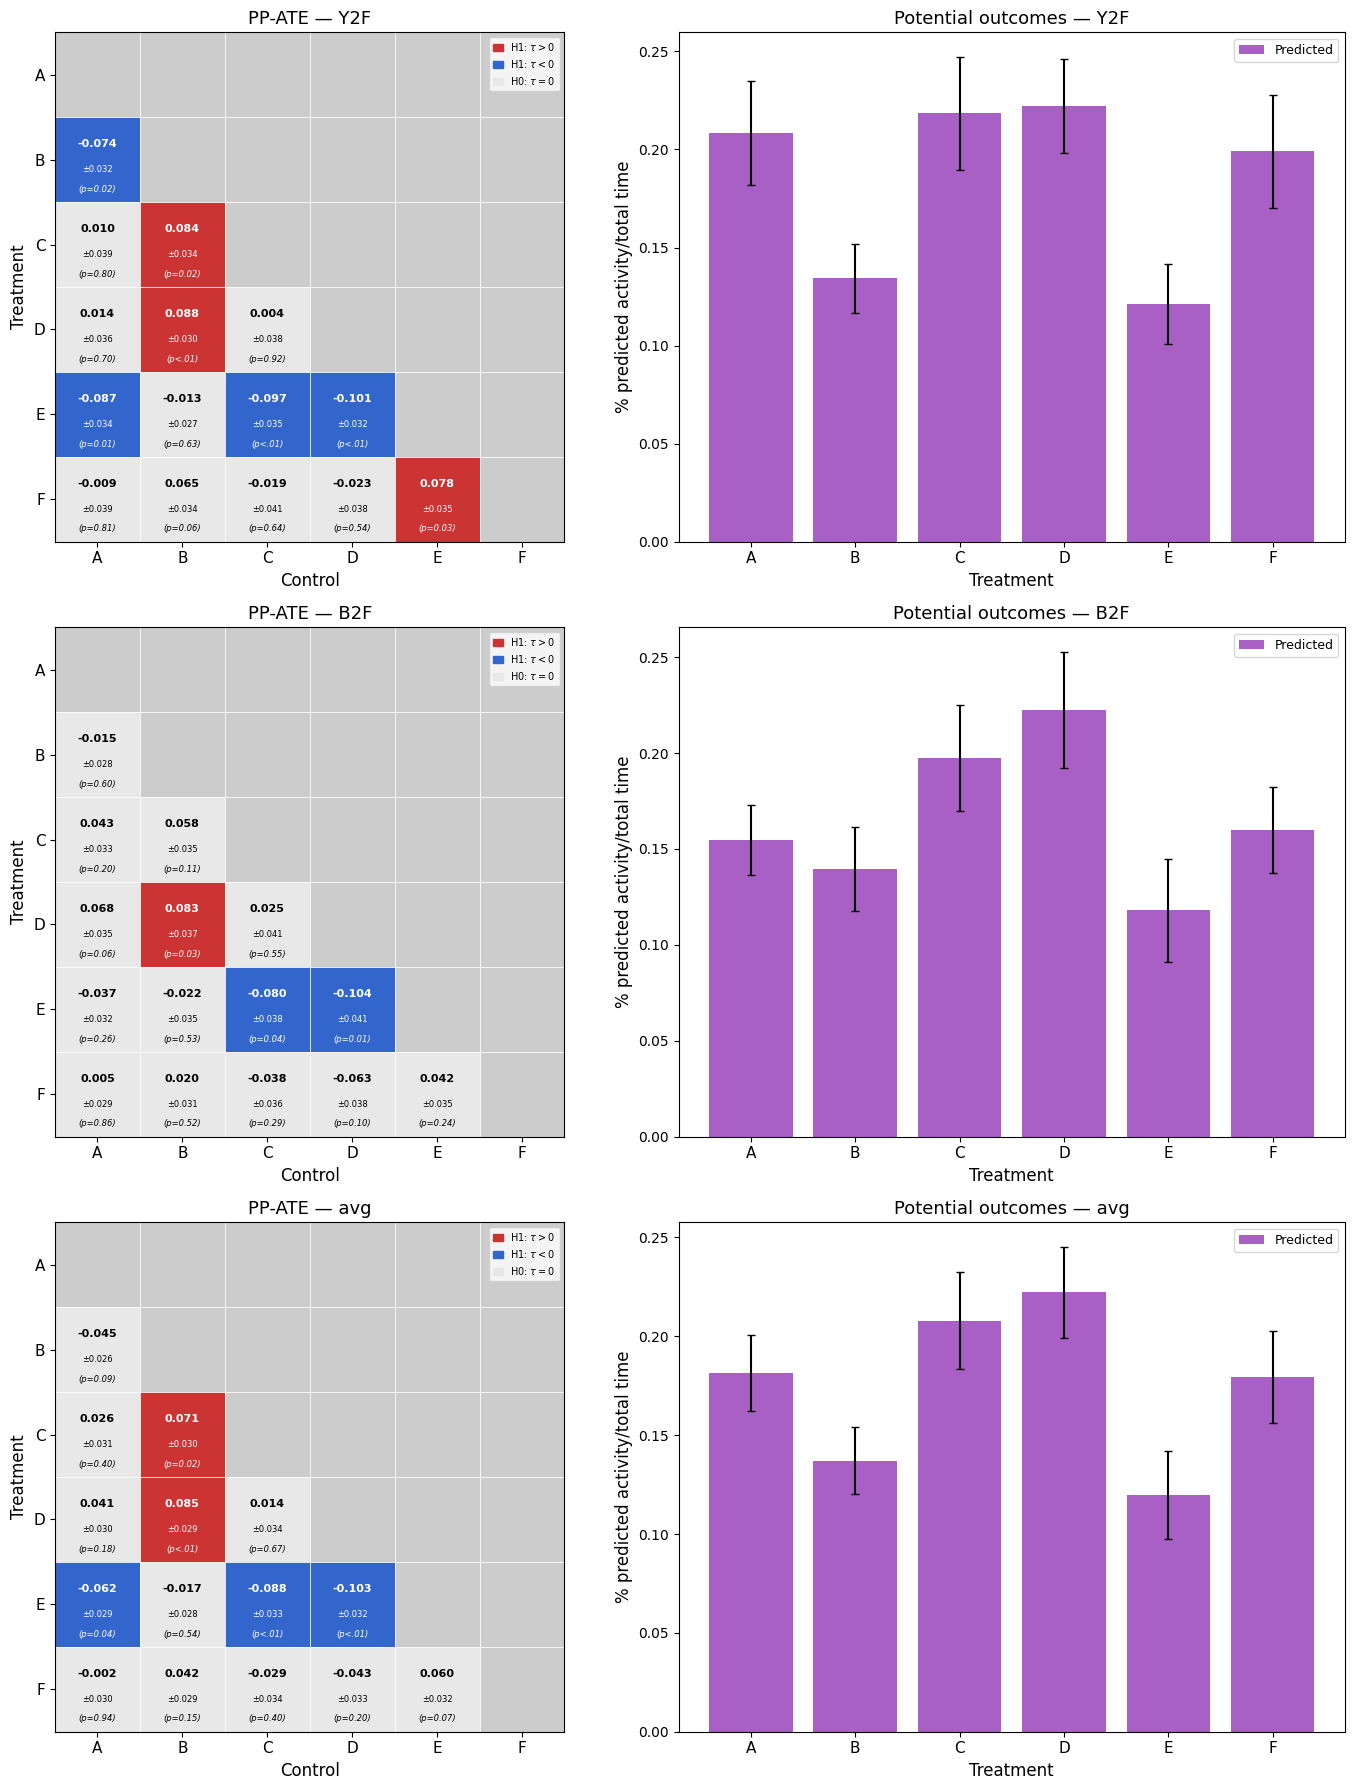

In [36]:
plot_summary(aggregate_to_observations(best_multi, ds_test, device), outcomes)